In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 2
rate = 10 
time = 1000
num_samples = 5
t0 = 200

In [4]:
# Simulation control parameters
g_values = [3, 5, 7, 9]

# Network parameters
N_E = 1000
gamma = 0.25
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.1
C_E = epsilon * N_E
C_ext = C_E

# Neuron parameters
tau = 20  * ms
theta = 20  * mV
V_r = 10  * mV
tau_rp = 2  * ms

# Synapse parameters
J = 0.1  * mV
D = 1.5  * ms

# Simulation settings
dt = 0.1  * ms
g = 7 # g is a good control for manipulating the firing rate
nu_ext_over_nu_thr = 2
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

Generating spike trains, then counting the spikes.

In [6]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[{0: array([0.1452, 0.1479, 0.2499, 0.3497, 0.9884, 0.9939]) * second, 1: array([  9. , 114.7, 471.3, 646.8, 721.1, 828.6, 889.8]) * msecond}, {0: array([0.1804, 0.2616, 0.2759, 0.3198, 0.3387, 0.6   , 0.7299, 0.743 ,
       0.9435, 0.9982]) * second, 1: array([0.15  , 0.2315, 0.314 , 0.4585, 0.5081, 0.5289, 0.6146, 0.7289,
       0.8952, 0.9415, 0.9571]) * second}, {0: array([0.0415, 0.1608, 0.2976, 0.2985, 0.326 , 0.3485, 0.5269, 0.6585,
       0.8174, 0.8619]) * second, 1: array([0.1575, 0.184 , 0.2859, 0.4013, 0.8037, 0.993 ]) * second}, {0: array([0.082 , 0.2561, 0.279 , 0.4373, 0.5859, 0.6265, 0.7783, 0.8507]) * second, 1: array([ 27.9, 133.9, 468.1, 622. , 935.6, 957. ]) * msecond}, {0: array([ 71.4,  91.6, 323.5, 533.9, 647.7, 770.2]) * msecond, 1: array([0.0314, 0.1787, 0.2398, 0.5283, 0.5369, 0.6427, 0.7565, 0.9784,
       0.9868]) * second}]


In [7]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
print(loaded_spike_trains)

Spike trains saved to spike_trains.json
[{0: array([0.1452, 0.1479, 0.2499, 0.3497, 0.9884, 0.9939]) * second, 1: array([  9. , 114.7, 471.3, 646.8, 721.1, 828.6, 889.8]) * msecond}, {0: array([0.1804, 0.2616, 0.2759, 0.3198, 0.3387, 0.6   , 0.7299, 0.743 ,
       0.9435, 0.9982]) * second, 1: array([0.15  , 0.2315, 0.314 , 0.4585, 0.5081, 0.5289, 0.6146, 0.7289,
       0.8952, 0.9415, 0.9571]) * second}, {0: array([0.0415, 0.1608, 0.2976, 0.2985, 0.326 , 0.3485, 0.5269, 0.6585,
       0.8174, 0.8619]) * second, 1: array([0.1575, 0.184 , 0.2859, 0.4013, 0.8037, 0.993 ]) * second}, {0: array([0.082 , 0.2561, 0.279 , 0.4373, 0.5859, 0.6265, 0.7783, 0.8507]) * second, 1: array([ 27.9, 133.9, 468.1, 622. , 935.6, 957. ]) * msecond}, {0: array([ 71.4,  91.6, 323.5, 533.9, 647.7, 770.2]) * msecond, 1: array([0.0314, 0.1787, 0.2398, 0.5283, 0.5369, 0.6427, 0.7565, 0.9784,
       0.9868]) * second}]


In [8]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.1452, 0.1479, 0.2499, 0.3497, 0.9884, 0.9939]), 1: array([0.009 , 0.1147, 0.4713, 0.6468, 0.7211, 0.8286, 0.8898])}, {0: array([0.1804, 0.2616, 0.2759, 0.3198, 0.3387, 0.6   , 0.7299, 0.743 ,
       0.9435, 0.9982]), 1: array([0.15  , 0.2315, 0.314 , 0.4585, 0.5081, 0.5289, 0.6146, 0.7289,
       0.8952, 0.9415, 0.9571])}, {0: array([0.0415, 0.1608, 0.2976, 0.2985, 0.326 , 0.3485, 0.5269, 0.6585,
       0.8174, 0.8619]), 1: array([0.1575, 0.184 , 0.2859, 0.4013, 0.8037, 0.993 ])}, {0: array([0.082 , 0.2561, 0.279 , 0.4373, 0.5859, 0.6265, 0.7783, 0.8507]), 1: array([0.0279, 0.1339, 0.4681, 0.622 , 0.9356, 0.957 ])}, {0: array([0.0714, 0.0916, 0.3235, 0.5339, 0.6477, 0.7702]), 1: array([0.0314, 0.1787, 0.2398, 0.5283, 0.5369, 0.6427, 0.7565, 0.9784,
       0.9868])}]


In [9]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
print(binary_spikes[0][0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [10]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
print(count.shape)

(5, 2, 1000)


In [11]:
print(spike_count[0]) # first sample
print(count[0])

[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2

Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [13]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
print(raw_excitatory_spike_trains)

[{0: array([0.0128, 0.0227, 0.033 , 0.0442, 0.0542, 0.0662, 0.0788, 0.0934,
       0.0995, 0.1111, 0.1212, 0.131 , 0.1416, 0.153 , 0.1632, 0.1704,
       0.1832, 0.192 , 0.2023, 0.2133, 0.2266, 0.2375, 0.2483, 0.2601,
       0.2679, 0.2797, 0.2905, 0.3033, 0.3141, 0.3277, 0.3373, 0.3493,
       0.3584, 0.3696, 0.3784, 0.3894, 0.3975, 0.4102, 0.4212, 0.4325,
       0.444 , 0.4548, 0.4662, 0.4781, 0.4892, 0.5013, 0.5107, 0.5229,
       0.5348, 0.5439, 0.5516, 0.5631, 0.572 , 0.5822, 0.5943, 0.6033,
       0.6142, 0.624 , 0.6372, 0.6471, 0.6565, 0.666 , 0.6735, 0.6822,
       0.6933, 0.7022, 0.7118, 0.7212, 0.7296, 0.7384, 0.7475, 0.7601,
       0.7683, 0.7788, 0.7907, 0.8006, 0.81  , 0.8183, 0.8279, 0.8394,
       0.8502, 0.8626, 0.8744, 0.885 , 0.8944, 0.9027, 0.912 , 0.9242,
       0.9333, 0.9442, 0.9528, 0.9645, 0.9743, 0.9852, 0.995 ]) * second, 1: array([0.0132, 0.0285, 0.0393, 0.0507, 0.0616, 0.0736, 0.0849, 0.0982,
       0.1116, 0.1243, 0.1346, 0.1432, 0.1566, 0.1691, 0.1792, 0.1

In [14]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [15]:
# result = vary_g(sim, g_values)

In [16]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

print(excitatory_spike_trains[0])
print(inhibitory_spike_trains[0])

{0: array([0.0128, 0.0227, 0.033 , 0.0442, 0.0542, 0.0662, 0.0788, 0.0934,
       0.0995, 0.1111, 0.1212, 0.131 , 0.1416, 0.153 , 0.1632, 0.1704,
       0.1832, 0.192 , 0.2023, 0.2133, 0.2266, 0.2375, 0.2483, 0.2601,
       0.2679, 0.2797, 0.2905, 0.3033, 0.3141, 0.3277, 0.3373, 0.3493,
       0.3584, 0.3696, 0.3784, 0.3894, 0.3975, 0.4102, 0.4212, 0.4325,
       0.444 , 0.4548, 0.4662, 0.4781, 0.4892, 0.5013, 0.5107, 0.5229,
       0.5348, 0.5439, 0.5516, 0.5631, 0.572 , 0.5822, 0.5943, 0.6033,
       0.6142, 0.624 , 0.6372, 0.6471, 0.6565, 0.666 , 0.6735, 0.6822,
       0.6933, 0.7022, 0.7118, 0.7212, 0.7296, 0.7384, 0.7475, 0.7601,
       0.7683, 0.7788, 0.7907, 0.8006, 0.81  , 0.8183, 0.8279, 0.8394,
       0.8502, 0.8626, 0.8744, 0.885 , 0.8944, 0.9027, 0.912 , 0.9242,
       0.9333, 0.9442, 0.9528, 0.9645, 0.9743, 0.9852, 0.995 ]), 1: array([0.0132, 0.0285, 0.0393, 0.0507, 0.0616, 0.0736, 0.0849, 0.0982,
       0.1116, 0.1243, 0.1346, 0.1432, 0.1566, 0.1691, 0.1792, 0.1915,
     

In [17]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

print(binary_ex_spikes[0][0]) # first sample of first neuron

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.

In [18]:
spike_count_ex = count_spikes(binary_ex_spikes)
print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
print(count_ex[0])
print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
print(count_in.shape)

[array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
        4.,  4.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,
        5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,
        7.,  7.,  8.,  8.,  8.,  8.,  8.,  8.,  9.,  9.,  9.,  9.,  9.,
        9.,  9.,  9.,  9.,  9.,  9.,  9., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 11., 11., 11., 11., 11., 11., 11., 11., 11.,
       11., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 13., 13.,
       13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 14., 14., 14.,
       14., 14., 14., 14., 14., 14., 14., 15., 15., 15., 15., 15., 15.,
       15., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 1

Theoretical and Empirical stats of raw counts.

In [20]:
theoretical_means = calculate_theoretical_mean(rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.   0.01 0.02 ... 9.97 9.98 9.99]
 [0.   0.01 0.02 ... 9.97 9.98 9.99]]
(2, 1000)
[[0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]
 [0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]]
(2, 1000)


In [21]:
empirical_mean = empirical_means(count)
print(empirical_mean)
print(empirical_mean.shape)

empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[0.  0.  0.  ... 7.8 8.  8. ]
 [0.  0.  0.  ... 7.8 7.8 7.8]]
(2, 1000)
[[0.         0.         0.         ... 1.78885438 2.         2.        ]
 [0.         0.         0.         ... 2.16794834 2.16794834 2.16794834]]
(2, 1000)


Theoretical and Empirical stats of excitatory counts.

In [23]:
empirical_mean_ex = empirical_means(count_ex)
print(empirical_mean_ex)
# print(empirical_mean_ex.shape)

[[ 0.   0.   0.  ... 94.8 94.8 95. ]
 [ 0.   0.   0.  ... 77.  77.  77. ]]


In [24]:
empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

[[0.         0.         0.         ... 1.09544512 1.09544512 1.41421356]
 [0.         0.         0.         ... 1.22474487 1.22474487 1.22474487]]
(2, 1000)


In [25]:
empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)

Theoretical and Empirical stats of inhibitory counts.

In [27]:
empirical_mean_in = empirical_means(count_in)
print(empirical_mean_in)
print(empirical_mean_in.shape)

[[ 0.   0.   0.  ... 84.  84.  84. ]
 [ 0.   0.   0.  ... 69.8 70.  70. ]]
(2, 1000)


In [28]:
empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

[[0.         0.         0.         ... 0.70710678 0.70710678 0.70710678]
 [0.         0.         0.         ... 1.09544512 1.22474487 1.22474487]]
(2, 1000)


In [29]:
empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)

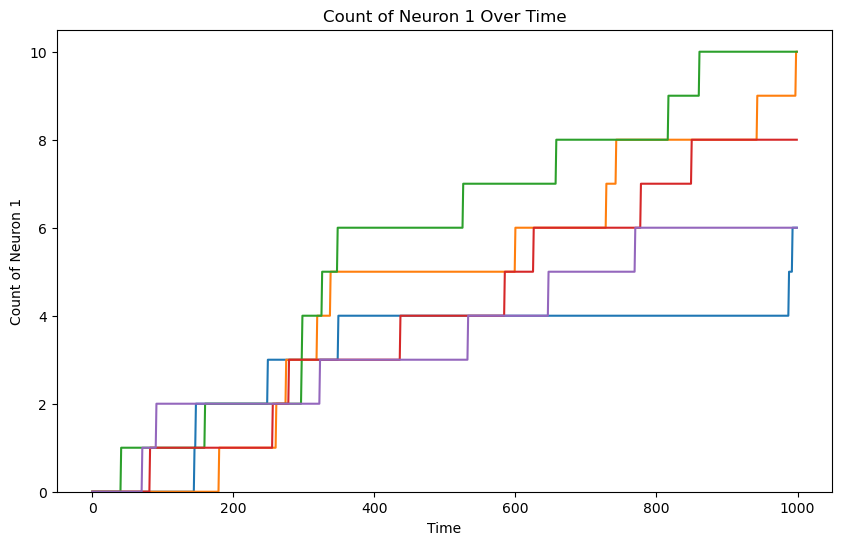

In [30]:
plot_count_neuron1_vs_time(count, num_samples)

Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

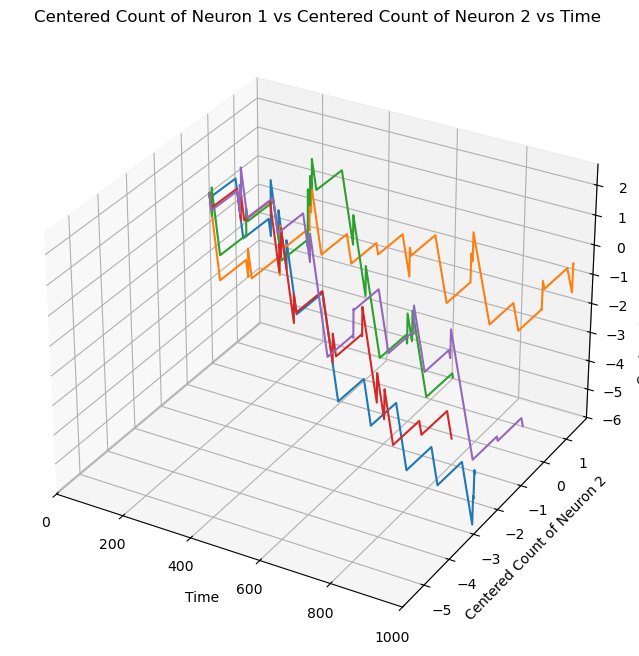

In [32]:
plot_centered_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_23632\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_23632\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


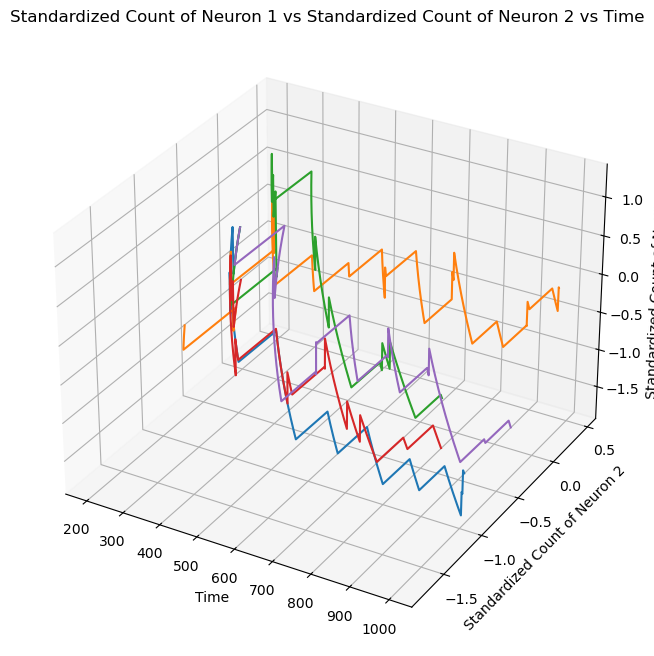

In [33]:
plot_standardized_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev, t0)

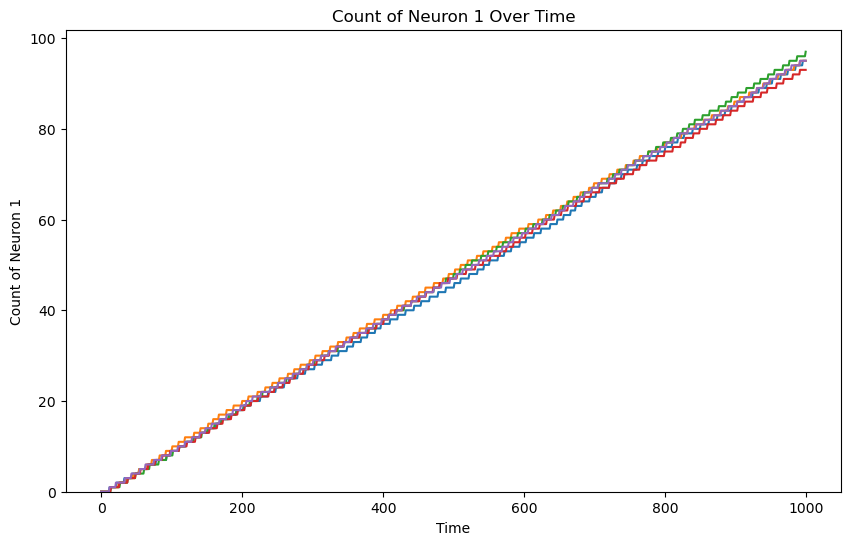

In [34]:
plot_count_neuron1_vs_time(count_ex, num_samples)

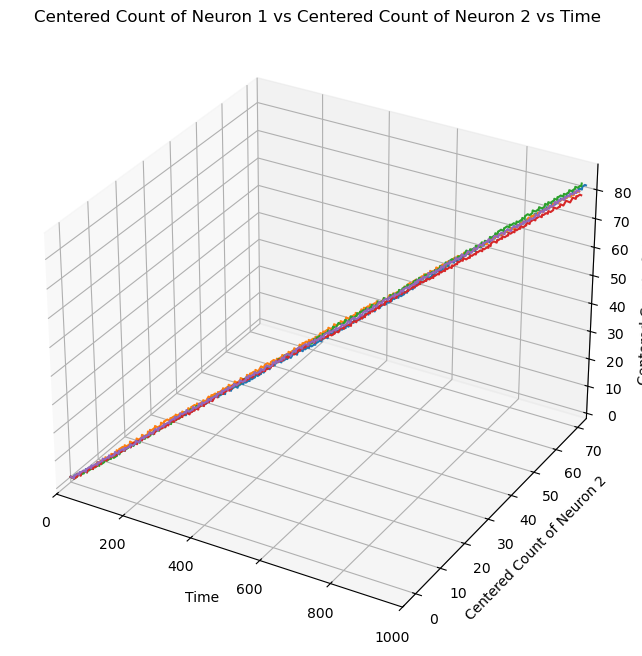

In [35]:
plot_centered_staircase_3d(count_ex, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_23632\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_23632\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


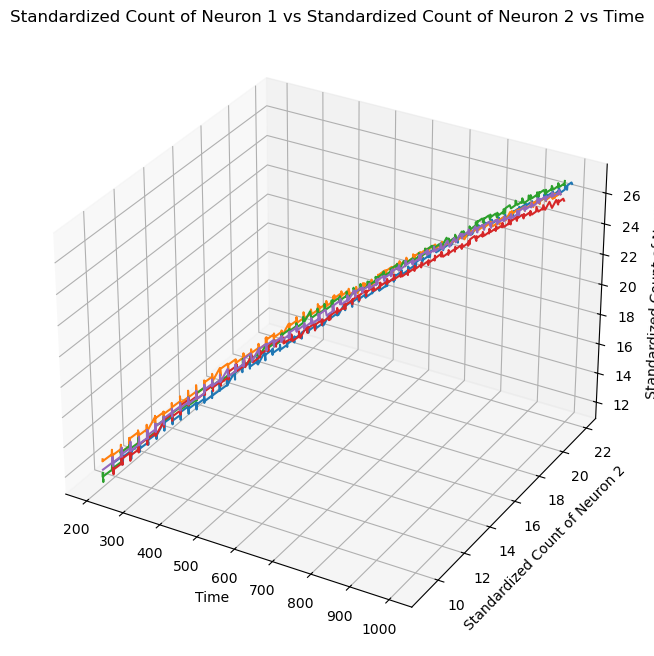

In [36]:
plot_standardized_staircase_3d(count_ex, num_samples, theoretical_means, theoretical_std_dev, t0)

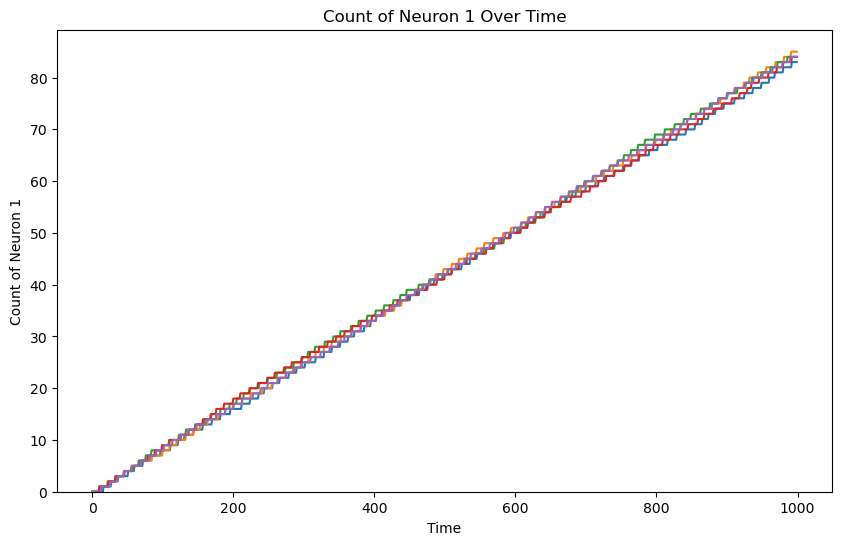

In [37]:
plot_count_neuron1_vs_time(count_in, num_samples)

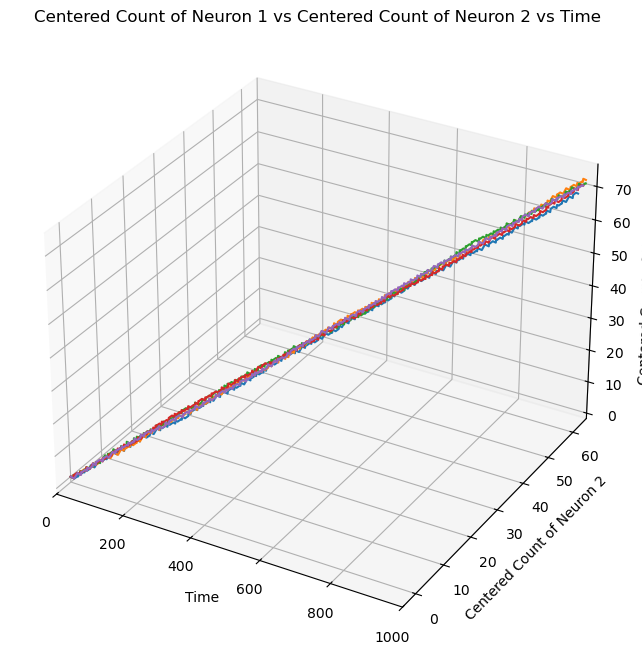

In [38]:
plot_centered_staircase_3d(count_in, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_23632\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_23632\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


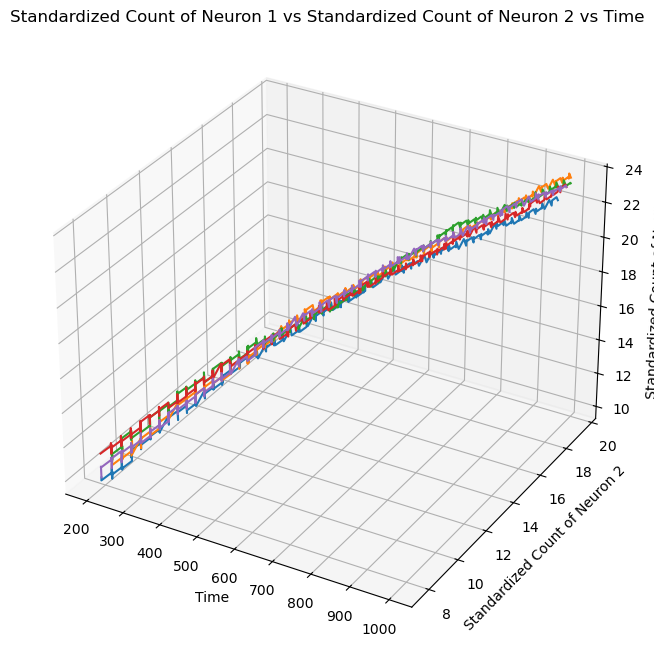

In [39]:
plot_standardized_staircase_3d(count_in, num_samples, theoretical_means, theoretical_std_dev, t0)